<h1>Import</h1>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import poisson
from collections import Counter

np.random.seed(42)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from understatapi import UnderstatClient
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

plt.style.use('dark_background')

SEASONS   = ["2022", "2023", "2024", "2025"]
ROLL_N    = 5
SEQ_LEN   = 10
SEQ_FEATS = 5

TCN_GATE_THRESHOLD = 0.05

<h1>Home Away Team

In [2]:
HOME_TEAM = "Burnley"
AWAY_TEAM = "Manchester City"

<h1>DATA INGESTION & ELO SYSTEM<h1>

In [5]:
def fetch_data(seasons):
    print(f"Mengambil data EPL musim {seasons}...")
    understat = UnderstatClient()
    rows = []
    for season in seasons:
        matches = understat.league("EPL").get_match_data(season=season)
        for m in matches:
            if m["goals"]["h"] is None:
                continue
            rows.append({
                "home_team":  m["h"]["title"],
                "away_team":  m["a"]["title"],
                "home_goals": int(m["goals"]["h"]),
                "away_goals": int(m["goals"]["a"]),
                "home_xg":    float(m["xG"]["h"]),
                "away_xg":    float(m["xG"]["a"]),
                "date":       pd.to_datetime(m["datetime"])
            })
    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    return df
def compute_elo(df, k_base=20, mov_cap=4):
    teams = set(df.home_team) | set(df.away_team)
    elo   = {t: 1500 for t in teams}
    h_list, a_list = [], []
    for _, r in df.iterrows():
        Rh, Ra = elo[r.home_team], elo[r.away_team]
        h_list.append(Rh); a_list.append(Ra)
        Eh = 1 / (1 + 10 ** ((Ra - Rh) / 400))
        S  = 1 if r.home_goals > r.away_goals else (0 if r.home_goals < r.away_goals else 0.5)

        goal_diff = abs(r.home_goals - r.away_goals)
        k_dynamic = k_base * np.log1p(min(goal_diff, mov_cap))

        elo[r.home_team] += k_dynamic * (S - Eh)
        elo[r.away_team] += k_dynamic * ((1 - S) - (1 - Eh))
    df["home_elo"] = h_list
    df["away_elo"] = a_list
    print(f"Data dimuat. Total laga: {len(df)}")
    return df, elo

df, final_elo = compute_elo(fetch_data(SEASONS))

Mengambil data EPL musim ['2022', '2023', '2024', '2025']...
Data dimuat. Total laga: 1470


<h1>FEATURE ENGINEERING

In [6]:
def get_last_matches(df, team, date, n=5):
    return df[
        ((df.home_team == team) | (df.away_team == team)) & (df.date < date)
    ].tail(n)

def weighted_avg(vals):
    k = len(vals)
    if k == 0: return 0.0
    weights = np.exp(np.linspace(0, 1, k))
    return float(np.average(vals, weights=weights))

def get_recent_points(df, team, date, n=5):
    matches = get_last_matches(df, team, date, n)
    pts = []
    for _, m in matches.iterrows():
        if m.home_team == team:
            pts.append(3 if m.home_goals > m.away_goals else (1 if m.home_goals == m.away_goals else 0))
        else:
            pts.append(3 if m.away_goals > m.home_goals else (1 if m.away_goals == m.home_goals else 0))
    return sum(pts) / (3 * n) if pts else 0.5

def get_clean_sheet_rate(df, team, date, n=5):
    matches = get_last_matches(df, team, date, n)
    cs = [1 if (m.away_goals if m.home_team == team else m.home_goals) == 0 else 0
          for _, m in matches.iterrows()]
    return np.mean(cs) if cs else 0.0

def get_fixture_congestion(df, team, date, days=14):
    cutoff  = date - pd.Timedelta(days=days)
    matches = df[((df.home_team == team) | (df.away_team == team))
                 & (df.date >= cutoff) & (df.date < date)]
    return len(matches)

def get_home_advantage(df, team, date, n=20):
    matches = get_last_matches(df, team, date, n)
    home_pts, away_pts = [], []
    for _, m in matches.iterrows():
        if m.home_team == team:
            home_pts.append(3 if m.home_goals > m.away_goals else (1 if m.home_goals == m.away_goals else 0))
        else:
            away_pts.append(3 if m.away_goals > m.home_goals else (1 if m.away_goals == m.home_goals else 0))
    return (np.mean(home_pts) if home_pts else 1.0) - (np.mean(away_pts) if away_pts else 1.0)

def poisson_outcome_probs(hx, ax, rho=0.15):
    from scipy.stats import poisson as pois
    max_g = 8
    ph, pd_, pa = 0.0, 0.0, 0.0
    for i in range(max_g + 1):
        for j in range(max_g + 1):
            if i == 0 and j == 0: tau = 1 - hx * ax * rho
            elif i == 1 and j == 0: tau = 1 + ax * rho
            elif i == 0 and j == 1: tau = 1 + hx * rho
            elif i == 1 and j == 1: tau = 1 - rho
            else: tau = 1.0
            p = pois.pmf(i, hx) * pois.pmf(j, ax) * tau
            if i > j:   ph  += p
            elif i < j: pa  += p
            else:       pd_ += p
    total = ph + pd_ + pa
    return ph / total, pd_ / total, pa / total

def build_features(df):
    rows = []
    for _, r in df.iterrows():
        h = get_last_matches(df, r.home_team, r.date, ROLL_N)
        a = get_last_matches(df, r.away_team, r.date, ROLL_N)
        if len(h) < 3 or len(a) < 3:
            continue

        h_g = weighted_avg([m.home_goals if m.home_team == r.home_team else m.away_goals for _, m in h.iterrows()])
        a_g = weighted_avg([m.home_goals if m.home_team == r.away_team else m.away_goals for _, m in a.iterrows()])
        h_x = weighted_avg([m.home_xg   if m.home_team == r.home_team else m.away_xg   for _, m in h.iterrows()])
        a_x = weighted_avg([m.home_xg   if m.home_team == r.away_team else m.away_xg   for _, m in a.iterrows()])
        h_ga= weighted_avg([m.away_goals if m.home_team == r.home_team else m.home_goals for _, m in h.iterrows()])
        a_ga= weighted_avg([m.away_goals if m.home_team == r.away_team else m.home_goals for _, m in a.iterrows()])
        h_xa= weighted_avg([m.away_xg   if m.home_team == r.home_team else m.home_xg   for _, m in h.iterrows()])
        a_xa= weighted_avg([m.away_xg   if m.home_team == r.away_team else m.home_xg   for _, m in a.iterrows()])

        h_pts  = get_recent_points(df, r.home_team, r.date, ROLL_N)
        a_pts  = get_recent_points(df, r.away_team, r.date, ROLL_N)
        h_cs   = get_clean_sheet_rate(df, r.home_team, r.date, ROLL_N)
        a_cs   = get_clean_sheet_rate(df, r.away_team, r.date, ROLL_N)
        h_hadv = get_home_advantage(df, r.home_team, r.date)
        h_fix  = get_fixture_congestion(df, r.home_team, r.date)
        a_fix  = get_fixture_congestion(df, r.away_team, r.date)

        h2h    = df[(df.home_team == r.home_team) & (df.away_team == r.away_team) & (df.date < r.date)].tail(5)
        h2h_wr = (h2h.home_goals > h2h.away_goals).mean() if len(h2h) > 0 else 0.5

        elo_factor  = 10 ** ((r.home_elo - r.away_elo) / 400)
        total_xg    = h_x + a_x
        adj_h_x     = 0.5 * h_x + 0.5 * total_xg * elo_factor / (elo_factor + 1)
        adj_a_x     = 0.5 * a_x + 0.5 * total_xg / (elo_factor + 1)
        pois_h, pois_d, pois_a = poisson_outcome_probs(adj_h_x, adj_a_x)

        h_xg_eff = h_g / (h_x + 1e-6) - 1.0
        a_xg_eff = a_g / (a_x + 1e-6) - 1.0
        h_def_eff = h_ga / (h_xa + 1e-6) - 1.0
        a_def_eff = a_ga / (a_xa + 1e-6) - 1.0

        y = "H" if r.home_goals > r.away_goals else ("A" if r.home_goals < r.away_goals else "D")
        rows.append({
            "date": r.date, "home_team": r.home_team, "away_team": r.away_team,
            "home_avg_goals": h_g, "away_avg_goals": a_g, "diff_goals": h_g - a_g,
            "home_avg_xg":    h_x, "away_avg_xg":    a_x, "diff_xg":    h_x - a_x,
            "home_avg_ga":    h_ga,"away_avg_ga":    a_ga, "diff_ga":   h_ga - a_ga,
            "home_avg_xa":    h_xa,"away_avg_xa":    a_xa, "diff_xa":   h_xa - a_xa,
            "home_pts_rate":  h_pts,"away_pts_rate": a_pts,"diff_pts":  h_pts - a_pts,
            "home_cs_rate":   h_cs, "away_cs_rate":  a_cs, "diff_cs":  h_cs - a_cs,
            "home_advantage": h_hadv,
            "home_fixture_load": h_fix,"away_fixture_load": a_fix,"diff_fix": h_fix - a_fix,
            "elo_diff": r.home_elo - r.away_elo,"h2h_home_winrate": h2h_wr,
            "pois_home_win":  pois_h,"pois_draw":      pois_d,"pois_away_win":  pois_a,
            "pois_h_minus_a": pois_h - pois_a,
            "home_xg_eff":    h_xg_eff,"away_xg_eff":  a_xg_eff,
            "home_def_eff":   h_def_eff,"away_def_eff": a_def_eff,
            "result": y
        })
    return pd.DataFrame(rows)

train_full = build_features(df)
le = LabelEncoder()
y  = le.fit_transform(train_full.result)
X  = train_full.drop(columns=["result","date","home_team","away_team"])
print(f"Dataset: {X.shape[1]} fitur, {X.shape[0]} baris")
print("Mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

Dataset: 32 fitur, 1425 baris
Mapping: {'A': 0, 'D': 1, 'H': 2}


<h1>LightGBM

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    m = lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.05,
        random_state=42, verbose=-1
    )
    m.fit(X.iloc[tr_idx], y[tr_idx])
    cv_scores.append(log_loss(y[val_idx], m.predict_proba(X.iloc[val_idx])))
print(f"TS-CV LogLoss: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

split    = int(0.8 * len(X))
Xtr, Xte = X.iloc[:split], X.iloc[split:]
ytr, yte  = y[:split],      y[split:]

if OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
            "max_depth":         trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
            "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "random_state": 42, "verbose": -1,
        }
        m = lgb.LGBMClassifier(**params)
        m.fit(Xtr, ytr)
        return log_loss(yte, m.predict_proba(Xte))
    print("Bayesian tuning (50 trials)")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)
    best_params = {**study.best_params, "random_state": 42, "verbose": -1}
    lgbm = lgb.LGBMClassifier(**best_params)
else:
    lgbm = lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        random_state=42, verbose=-1
    )

lgbm.fit(Xtr, ytr)

TS-CV LogLoss: 2.0315 ± 0.1758
Bayesian tuning (50 trials)


LGBMClassifier(colsample_bytree=0.6940230457666766,
               learning_rate=0.010910278566978163, max_depth=12,
               n_estimators=677, num_leaves=33, random_state=42,
               reg_alpha=9.790198581649268, reg_lambda=0.00015204957789974606,
               subsample=0.8795843537204106, verbose=-1)

<h1>Kalibrasi Ganda

In [8]:
calib_cut = int(0.875 * len(Xtr))
Xtr_base, Xtr_cal = Xtr.iloc[:calib_cut], Xtr.iloc[calib_cut:]
ytr_base, ytr_cal = ytr[:calib_cut], ytr[calib_cut:]

dates_base = train_full.iloc[:split].iloc[:calib_cut]["date"]
dates_cal  = train_full.iloc[:split].iloc[calib_cut:]["date"]
if len(dates_base) > 0 and len(dates_cal) > 0:
    overlap = dates_base.max() >= dates_cal.min()
    if overlap:
        print("WARNING: Potensi tanggal overlap di split kalibrasi! Periksa sorting data.")
    else:
        print(f"Split kalibrasi aman: base ends {dates_base.max().date()}, cal starts {dates_cal.min().date()}")

lgbm_base = lgb.LGBMClassifier(**lgbm.get_params())
lgbm_base.fit(Xtr_base, ytr_base)

calib_iso = CalibratedClassifierCV(lgbm_base, method="isotonic", cv="prefit")
calib_sig = CalibratedClassifierCV(lgbm_base, method="sigmoid",  cv="prefit")
calib_iso.fit(Xtr_cal, ytr_cal)
calib_sig.fit(Xtr_cal, ytr_cal)

p_iso = calib_iso.predict_proba(Xte)
p_sig = calib_sig.predict_proba(Xte)
ll_iso = log_loss(yte, p_iso)
ll_sig = log_loss(yte, p_sig)
print(f"\nKALIBRASI:")
print(f"   Isotonic  LogLoss: {ll_iso:.4f}")
print(f"   Sigmoid   LogLoss: {ll_sig:.4f}")

if ll_iso <= ll_sig:
    calib = calib_iso
    p_lgbm_val = p_iso
    best_calib_name = "Isotonic"
else:
    calib = calib_sig
    p_lgbm_val = p_sig
    best_calib_name = "Sigmoid"

print(f"Dipilih: {best_calib_name}  (LogLoss: {min(ll_iso, ll_sig):.4f})")

def reliability_data(y_true, p_pred, n_bins=10):
    results = {}
    for cls_idx in range(p_pred.shape[1]):
        is_cls   = (y_true == cls_idx).astype(int)
        p_cls    = p_pred[:, cls_idx]
        bins     = np.linspace(0, 1, n_bins + 1)
        frac_pos, mean_pred = [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (p_cls >= lo) & (p_cls < hi)
            if mask.sum() > 0:
                frac_pos.append(is_cls[mask].mean())
                mean_pred.append(p_cls[mask].mean())
        results[cls_idx] = (np.array(mean_pred), np.array(frac_pos))
    return results

rel_before = reliability_data(yte, lgbm_base.predict_proba(Xte))
rel_after  = reliability_data(yte, p_lgbm_val)

Split kalibrasi aman: base ends 2025-03-09, cal starts 2025-03-09

KALIBRASI:
   Isotonic  LogLoss: 1.5269
   Sigmoid   LogLoss: 1.0327
Dipilih: Sigmoid  (LogLoss: 1.0327)


<h1>1D TCN

In [10]:
seq_scaler = StandardScaler()

def build_sequence(df, team, date, elo_dict):
    matches = get_last_matches(df, team, date, SEQ_LEN)
    seq = []
    for _, m in matches.iterrows():
        is_home = (m.home_team == team)
        goals   = m.home_goals if is_home else m.away_goals
        xg      = m.home_xg   if is_home else m.away_xg
        xga     = m.away_xg   if is_home else m.home_xg
        g_opp   = m.away_goals if is_home else m.home_goals
        result  = 1 if goals > g_opp else (0 if goals == g_opp else -1)
        opp     = m.away_team if is_home else m.home_team
        opp_elo = elo_dict.get(opp, 1500) / 1500.0
        seq.append([goals, xg, xga, result, opp_elo])
    while len(seq) < SEQ_LEN:
        seq.insert(0, [0.0, 0.0, 0.0, 0.0, 1.0])
    return np.array(seq, dtype=np.float32)

X_seq = []
for _, r in train_full.iterrows():
    seq_h = build_sequence(df, r.home_team, r.date, final_elo)
    seq_a = build_sequence(df, r.away_team, r.date, final_elo)
    X_seq.append(np.concatenate([seq_h, seq_a], axis=1))

X_seq = np.array(X_seq)
Xtr_seq, Xte_seq = X_seq[:split], X_seq[split:]
ytr_seq, yte_seq = y[:split], y[split:]

orig_shape = Xtr_seq.shape
seq_scaler.fit(Xtr_seq.reshape(-1, orig_shape[-1]))
Xtr_seq = seq_scaler.transform(Xtr_seq.reshape(-1, orig_shape[-1])).reshape(orig_shape)
Xte_seq = seq_scaler.transform(Xte_seq.reshape(-1, orig_shape[-1])).reshape(Xte_seq.shape)

# TCN input shape: (batch, features, seq_len) — channel-first untuk Conv1d
Xtr_seq_t = np.transpose(Xtr_seq, (0, 2, 1))  # (N, C, L)
Xte_seq_t = np.transpose(Xte_seq, (0, 2, 1))

dataset = TensorDataset(
    torch.tensor(Xtr_seq_t, dtype=torch.float32),
    torch.tensor(ytr_seq, dtype=torch.long)
)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

class DilatedResBlock(nn.Module):
    """
    Causal dilated conv + residual connection.
    Padding = (kernel-1)*dilation untuk memastikan causal (tidak bocor ke masa depan).
    """
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1, dropout=0.2):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation)
        )
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation)
        )
        self.dropout = nn.Dropout(dropout)
        self.chomp   = lambda x, p: x[:, :, :-p] if p > 0 else x 
        self.pad     = pad
        self.proj = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp(out, self.pad)
        out = F.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.chomp(out, self.pad)
        out = F.relu(out)
        out = self.dropout(out)
        res = self.proj(x) if self.proj else x
        return F.relu(out + res)


class TCNModel(nn.Module):
    def __init__(self, input_size=SEQ_FEATS * 2, n_filters=32, dropout=0.2):
        super().__init__()
        self.blocks = nn.Sequential(
            DilatedResBlock(input_size, n_filters, dilation=1, dropout=dropout),
            DilatedResBlock(n_filters,  n_filters, dilation=2, dropout=dropout),
            DilatedResBlock(n_filters,  n_filters, dilation=4, dropout=dropout),
        )
        self.fc1 = nn.Linear(n_filters, 32)
        self.fc2 = nn.Linear(32, 3)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        out = self.blocks(x)
        out = out.mean(dim=-1)
        out = F.relu(self.fc1(self.drop(out)))
        return self.fc2(out)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


tcn_model = TCNModel()
print(f"\nTCN model params: {tcn_model.count_params():,}  (vs Bi-LSTM ~70K)")

opt       = torch.optim.AdamW(tcn_model.parameters(), lr=0.003, weight_decay=5e-4)
loss_fn   = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)

print("Training TCN (30 epoch)...")
for epoch in range(30):
    tcn_model.train()
    ep_loss = 0
    for bX, by in loader:
        opt.zero_grad()
        loss = loss_fn(tcn_model(bX), by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tcn_model.parameters(), 1.0)
        opt.step()
        ep_loss += loss.item()
    scheduler.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/30 | Loss: {ep_loss/len(loader):.4f}")

tcn_model.eval()
with torch.no_grad():
    p_tcn_val = torch.softmax(
        tcn_model(torch.tensor(Xte_seq_t, dtype=torch.float32)), dim=1
    ).numpy()

ll_lgbm = log_loss(yte, p_lgbm_val)
ll_tcn  = log_loss(yte, p_tcn_val)
print(f"\nLogLoss perbandingan: LGBM={ll_lgbm:.4f}  TCN={ll_tcn:.4f}")


tcn_relative_worse = (ll_tcn - ll_lgbm) / ll_lgbm
if tcn_relative_worse > TCN_GATE_THRESHOLD:
    print(f"TCN di-gate (relatif {tcn_relative_worse*100:.1f}% lebih buruk dari LGBM).")
    print(f"Ensemble akan menggunakan LGBM 100%.")
    BEST_WEIGHT = 1.0
    TCN_GATED   = True
else:
    TCN_GATED = False
    best_w, best_loss = 1.0, 999
    for w in np.arange(0.1, 1.0, 0.05):
        ll = log_loss(yte, w * p_lgbm_val + (1 - w) * p_tcn_val)
        if ll < best_loss:
            best_loss, best_w = ll, w
    BEST_WEIGHT = best_w
    print(f"Ensemble: LGBM={best_w:.2f}, TCN={1-best_w:.2f} | LogLoss: {best_loss:.4f}")


TCN model params: 18,211  (vs Bi-LSTM ~70K)
Training TCN (30 epoch)...
  Epoch 5/30 | Loss: 0.9940
  Epoch 10/30 | Loss: 0.9804
  Epoch 15/30 | Loss: 0.9649
  Epoch 20/30 | Loss: 0.9439
  Epoch 25/30 | Loss: 0.9238
  Epoch 30/30 | Loss: 0.9130

LogLoss perbandingan: LGBM=1.0327  TCN=1.0820
Ensemble: LGBM=0.80, TCN=0.20 | LogLoss: 1.0305


<h1>KONSISTENSI ML vs POISSON — alignment check & blend

In [11]:
def adjust_xg_by_elo(h_xg, a_xg, h_elo, a_elo):
    ef    = 10 ** ((h_elo - a_elo) / 400)
    total = h_xg + a_xg
    adj_h = 0.5 * h_xg + 0.5 * total * ef / (ef + 1)
    adj_a = 0.5 * a_xg + 0.5 * total / (ef + 1)
    return round(adj_h, 4), round(adj_a, 4)

def alignment_score(p_ml, p_pois):
    p_ml   = np.clip(p_ml,   1e-9, 1)
    p_pois = np.clip(p_pois, 1e-9, 1)
    return float(np.sum(p_ml * np.log(p_ml / p_pois)))

def blend_ml_poisson(p_ml, p_pois, kl_div, kl_threshold=0.05):
    alpha   = max(0.5, 1.0 - kl_div / kl_threshold)
    alpha   = min(alpha, 1.0)
    blended = alpha * np.array(p_ml) + (1 - alpha) * np.array(p_pois)
    return blended / blended.sum(), alpha

def predict_match(home, away):
    assert home in final_elo, f"Tim '{home}' tidak ditemukan!"
    assert away in final_elo, f"Tim '{away}' tidak ditemukan!"

    future = df.date.max() + pd.Timedelta(days=1)
    hp = get_last_matches(df, home, future, ROLL_N)
    ap = get_last_matches(df, away, future, ROLL_N)

    h_g = weighted_avg([m.home_goals if m.home_team == home else m.away_goals for _, m in hp.iterrows()])
    a_g = weighted_avg([m.home_goals if m.home_team == away else m.away_goals for _, m in ap.iterrows()])
    h_x = weighted_avg([m.home_xg   if m.home_team == home else m.away_xg   for _, m in hp.iterrows()])
    a_x = weighted_avg([m.home_xg   if m.home_team == away else m.away_xg   for _, m in ap.iterrows()])
    h_ga= weighted_avg([m.away_goals if m.home_team == home else m.home_goals for _, m in hp.iterrows()])
    a_ga= weighted_avg([m.away_goals if m.home_team == away else m.home_goals for _, m in ap.iterrows()])
    h_xa= weighted_avg([m.away_xg   if m.home_team == home else m.home_xg   for _, m in hp.iterrows()])
    a_xa= weighted_avg([m.away_xg   if m.home_team == away else m.home_xg   for _, m in ap.iterrows()])

    h_elo, a_elo = final_elo.get(home, 1500), final_elo.get(away, 1500)
    adj_h_xg, adj_a_xg = adjust_xg_by_elo(h_x, a_x, h_elo, a_elo)

    h_pts  = get_recent_points(df, home, future, ROLL_N)
    a_pts  = get_recent_points(df, away, future, ROLL_N)
    h_cs   = get_clean_sheet_rate(df, home, future, ROLL_N)
    a_cs   = get_clean_sheet_rate(df, away, future, ROLL_N)
    h_hadv = get_home_advantage(df, home, future)
    h_fix  = get_fixture_congestion(df, home, future)
    a_fix  = get_fixture_congestion(df, away, future)
    h2h    = df[(df.home_team == home) & (df.away_team == away)].tail(5)
    h2h_wr = (h2h.home_goals > h2h.away_goals).mean() if len(h2h) > 0 else 0.5

    pois_h, pois_d, pois_a = poisson_outcome_probs(adj_h_xg, adj_a_xg)
    h_xg_eff  = h_g / (h_x + 1e-6) - 1.0
    a_xg_eff  = a_g / (a_x + 1e-6) - 1.0
    h_def_eff = h_ga / (h_xa + 1e-6) - 1.0
    a_def_eff = a_ga / (a_xa + 1e-6) - 1.0

    Xp = pd.DataFrame([{
        "home_avg_goals": h_g, "away_avg_goals": a_g, "diff_goals": h_g - a_g,
        "home_avg_xg":    h_x, "away_avg_xg":    a_x, "diff_xg":    h_x - a_x,
        "home_avg_ga":    h_ga,"away_avg_ga":    a_ga, "diff_ga":   h_ga - a_ga,
        "home_avg_xa":    h_xa,"away_avg_xa":    a_xa, "diff_xa":   h_xa - a_xa,
        "home_pts_rate":  h_pts,"away_pts_rate": a_pts,"diff_pts":  h_pts - a_pts,
        "home_cs_rate":   h_cs, "away_cs_rate":  a_cs, "diff_cs":  h_cs - a_cs,
        "home_advantage": h_hadv,
        "home_fixture_load": h_fix,"away_fixture_load": a_fix,"diff_fix": h_fix - a_fix,
        "elo_diff": h_elo - a_elo,"h2h_home_winrate": h2h_wr,
        "pois_home_win": pois_h,"pois_draw": pois_d,"pois_away_win": pois_a,
        "pois_h_minus_a": pois_h - pois_a,
        "home_xg_eff": h_xg_eff,"away_xg_eff": a_xg_eff,
        "home_def_eff": h_def_eff,"away_def_eff": a_def_eff,
    }])
    p_lgbm_raw = calib.predict_proba(Xp)[0]

    if not TCN_GATED:
        seq_h = build_sequence(df, home, future, final_elo)
        seq_a = build_sequence(df, away, future, final_elo)
        seq   = np.concatenate([seq_h, seq_a], axis=1)
        seq_n = seq_scaler.transform(seq.reshape(-1, seq.shape[-1])).reshape(1, SEQ_LEN, -1)
        seq_n_t = np.transpose(seq_n, (0, 2, 1))
        tcn_model.eval()
        with torch.no_grad():
            p_tcn_raw = torch.softmax(
                tcn_model(torch.tensor(seq_n_t, dtype=torch.float32)), dim=1
            )[0].numpy()
        p_ensemble = BEST_WEIGHT * p_lgbm_raw + (1 - BEST_WEIGHT) * p_tcn_raw
    else:
        p_ensemble = p_lgbm_raw

    p_ensemble /= p_ensemble.sum()

    cls_order = list(le.classes_)
    pois_ordered = np.array([
        pois_h if cls_order[i] == "H" else (pois_d if cls_order[i] == "D" else pois_a)
        for i in range(3)
    ])

    kl = alignment_score(p_ensemble, pois_ordered)
    p_final, alpha_ml = blend_ml_poisson(p_ensemble, pois_ordered, kl)

    return (dict(zip(le.classes_, p_final)),
            adj_h_xg, adj_a_xg,
            dict(zip(le.classes_, p_ensemble)),
            dict(zip(le.classes_, pois_ordered)),
            kl, alpha_ml)

<h1>Monte Carlo Simulation

In [12]:
def dixon_coles_adj(i, j, hx, ax, rho=0.15):
    if i == 0 and j == 0: return 1 - hx * ax * rho
    if i == 1 and j == 0: return 1 + ax * rho
    if i == 0 and j == 1: return 1 + hx * rho
    if i == 1 and j == 1: return 1 - rho
    return 1.0

def build_score_matrix(hx, ax, max_goals=8, rho=0.15):
    N   = max_goals + 1
    mat = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            mat[i, j] = poisson.pmf(i, hx) * poisson.pmf(j, ax) * dixon_coles_adj(i, j, hx, ax, rho)
    return mat / mat.sum()

def run_monte_carlo(hx, ax, n_sims=10000, rho=0.15):
    mat  = build_score_matrix(hx, ax, rho=rho)
    flat = mat.flatten()
    idx  = np.random.choice(len(flat), size=n_sims, p=flat)
    N    = mat.shape[0]
    h_sc, a_sc = idx // N, idx % N
    scores = list(zip(h_sc.tolist(), a_sc.tolist()))
    return scores, Counter(scores), int((h_sc > a_sc).sum()), int((h_sc == a_sc).sum()), int((h_sc < a_sc).sum()), mat

<h1>Visualization

In [15]:
HOME_CLR = "#4fc3f7"
AWAY_CLR = "#ef9a9a"
DRAW_CLR = "#b0bec5"
CYAN_HL  = "#00e5ff"
GOLD     = "#ffd54f"
GREEN_HL = "#69f0ae"

def _truncate(name, n=12):
    return name if len(name) <= n else name[:n] + "…"

def plot_prob_donut(ax, prob, home, away):
    keys   = list(prob.keys())
    vals   = list(prob.values())
    colors = [HOME_CLR, DRAW_CLR, AWAY_CLR]
    wedges, _ = ax.pie(vals, colors=colors, startangle=90,
                       wedgeprops=dict(width=0.45, edgecolor="#111"))
    for w, v, c in zip(wedges, vals, colors):
        ang = (w.theta1 + w.theta2) / 2
        x   = 0.68 * np.cos(np.radians(ang))
        y   = 0.68 * np.sin(np.radians(ang))
        ax.text(x, y, f"{v*100:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")
    legend_items = [mpatches.Patch(color=c, label=f"{k}") for k, c in zip(keys, colors)]
    ax.legend(handles=legend_items, loc="lower center", ncol=3,
              fontsize=9, framealpha=0, bbox_to_anchor=(0.5, -0.08))
    ax.set_title(f"Final Probability (ML+Poisson blend)\n"
                 f"{_truncate(home,14)} vs {_truncate(away,14)}",
                 fontsize=11, fontweight="bold", pad=6)

def plot_alignment(ax, p_ml, p_pois, p_final, kl, alpha, home, away):
    labels = ["H Win", "Draw", "A Win"]
    def extract_hda(d):
        return [d.get("H", 0), d.get("D", 0), d.get("A", 0)]
    ml_v    = np.array(extract_hda(p_ml))
    pois_v  = np.array(extract_hda(p_pois))
    final_v = np.array(extract_hda(p_final))

    x = np.arange(3)
    w = 0.25
    ax.bar(x - w, ml_v * 100,    width=w, color=HOME_CLR, alpha=0.8, label="ML ensemble", edgecolor="#111")
    ax.bar(x,     pois_v * 100,  width=w, color=GOLD,     alpha=0.8, label="Poisson (xG)", edgecolor="#111")
    ax.bar(x + w, final_v * 100, width=w, color=GREEN_HL, alpha=0.8, label="Final (blend)", edgecolor="#111")

    for xi, fv in zip(x + w, final_v):
        ax.text(xi, fv * 100 + 1, f"{fv*100:.1f}%", ha="center", va="bottom",
                fontsize=8, color="white", fontweight="bold")

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Probability %", fontsize=9)
    ax.set_ylim(0, max(max(ml_v), max(pois_v), max(final_v)) * 130)
    ax.grid(axis="y", alpha=0.15)
    ax.legend(fontsize=8, framealpha=0, loc="upper right")
    kl_color = "#69f0ae" if kl < 0.02 else ("#ffd54f" if kl < 0.05 else "#ef9a9a")
    ax.set_title(
        f"ML vs Poisson Alignment  |  KL={kl:.4f}  α_ML={alpha:.2f}",
        fontsize=10, fontweight="bold", color=kl_color, pad=6
    )

def plot_reliability(ax, rel_before, rel_after, le):
    labels = le.classes_.tolist()
    colors_b = ["#7986cb", "#81c784", "#e57373"]
    colors_a = [HOME_CLR, GREEN_HL, AWAY_CLR]
    ax.plot([0, 1], [0, 1], "w--", lw=1, alpha=0.5, label="Perfect")
    for idx, (lbl, cb, ca) in enumerate(zip(labels, colors_b, colors_a)):
        mp_b, fp_b = rel_before.get(idx, ([], []))
        mp_a, fp_a = rel_after.get(idx, ([], []))
        if len(mp_b): ax.plot(mp_b, fp_b, "o--", color=cb, lw=1.2, ms=4, alpha=0.6, label=f"{lbl} (before)")
        if len(mp_a): ax.plot(mp_a, fp_a, "o-",  color=ca, lw=1.8, ms=5,            label=f"{lbl} ({best_calib_name})")
    ax.set_xlabel("Mean predicted probability", fontsize=9)
    ax.set_ylabel("Fraction of positives", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.12)
    ax.legend(fontsize=7, framealpha=0, ncol=2)
    ax.set_title(f"Reliability Diagram — {best_calib_name} calibration",
                 fontsize=10, fontweight="bold")

def plot_score_heatmap(ax, hx, ax_, home, away, max_goals=5):
    mat  = build_score_matrix(hx, ax_, max_goals=max_goals)
    disp = mat[:max_goals+1, :max_goals+1]
    best = np.unravel_index(np.argmax(disp), disp.shape)
    cmap_hw = LinearSegmentedColormap.from_list("hw", ["#0d1b2a", HOME_CLR])
    cmap_aw = LinearSegmentedColormap.from_list("aw", ["#1b0a0a", AWAY_CLR])
    cmap_dr = LinearSegmentedColormap.from_list("dr", ["#111",    DRAW_CLR])
    for i in range(max_goals+1):
        for j in range(max_goals+1):
            v = disp[i, j]
            c = cmap_hw(v/disp.max()*1.6) if i>j else (cmap_aw(v/disp.max()*1.6) if i<j else cmap_dr(v/disp.max()*1.6))
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=c))
            ax.text(j+.5, i+.5, f"{v*100:.2f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold" if (i,j)==best else "normal")
    bj, bi = best[1], best[0]
    ax.add_patch(plt.Rectangle((bj,bi),1,1,fill=False,edgecolor=CYAN_HL,lw=3,zorder=5))
    ax.set_xlim(0,max_goals+1); ax.set_ylim(0,max_goals+1)
    ax.set_xticks(np.arange(max_goals+1)+.5); ax.set_xticklabels(range(max_goals+1),fontsize=9)
    ax.set_yticks(np.arange(max_goals+1)+.5); ax.set_yticklabels(range(max_goals+1),fontsize=9)
    ax.set_xlabel(f"{_truncate(away)} Goals",fontsize=10); ax.set_ylabel(f"{_truncate(home)} Goals",fontsize=10)
    ax.set_title(f"Most Likely: {home} {best[0]}–{best[1]} {away}  ({disp[best]*100:.2f}%)\n"
                 f"ELO-adj xG — Home: {hx:.2f}  Away: {ax_:.2f}",
                 fontsize=10, fontweight="bold", color=CYAN_HL, pad=6)

def plot_mc_bar(ax, hw, dr, aw, n, prob, home, away):
    labels = [_truncate(home,11), "Draw", _truncate(away,11)]
    vals   = [hw, dr, aw]
    colors = [HOME_CLR, DRAW_CLR, AWAY_CLR]
    bars   = ax.bar(labels, vals, color=colors, width=0.55, edgecolor="#111", linewidth=0.8)
    order_map = {"H": 0, "D": 1, "A": 2}
    for k, pv in prob.items():
        idx = order_map.get(k)
        if idx is not None:
            ax.plot([idx-.27,idx+.27],[pv*n,pv*n],color=GOLD,lw=2.5,ls="--",zorder=5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+n*.008,
                f"{v}\n({v/n*100:.1f}%)", ha="center",va="bottom",fontsize=9,fontweight="bold",color="white")
    ax.set_ylabel("Simulations",fontsize=9); ax.set_ylim(0,max(vals)*1.18)
    ax.tick_params(axis="x",labelsize=10); ax.grid(axis="y",alpha=0.15)
    ax.legend(handles=[mpatches.Patch(color=GOLD,label="Final blend prob")],fontsize=8,framealpha=0,loc="upper right")
    ax.set_title(f"Monte Carlo Outcomes  ({n:,} sims)", fontsize=11, fontweight="bold")

def plot_mc_bubble(ax, counts, n, home, away, min_freq=100):
    filtered = {k: v for k, v in counts.items() if v >= min_freq}
    if not filtered:
        ax.text(0.5,0.5,"No scores above threshold",ha="center",va="center",transform=ax.transAxes,color="white")
        return
    max_c = max(filtered.values())
    for (hi,aj),cnt in filtered.items():
        color = HOME_CLR if hi>aj else (AWAY_CLR if aj>hi else DRAW_CLR)
        ax.scatter(aj,hi,s=(cnt/max_c)*1800+80,c=color,alpha=0.82,edgecolors="white",linewidth=0.8,zorder=3)
        ax.text(aj,hi,str(cnt),ha="center",va="center",color="black",fontweight="bold",fontsize=8 if cnt<max_c*.3 else 9,zorder=4)
    all_h=[k[0] for k in filtered]; all_a=[k[1] for k in filtered]
    ax.set_xlim(-0.7,max(all_a)+1.2); ax.set_ylim(-0.7,max(all_h)+1.2)
    ax.set_xticks(range(0,max(all_a)+2)); ax.set_yticks(range(0,max(all_h)+2))
    ax.set_xlabel(f"{_truncate(away)} Goals",fontsize=10); ax.set_ylabel(f"{_truncate(home)} Goals",fontsize=10)
    ax.grid(True,alpha=0.12); ax.set_title("Score Distribution (freq ≥ 100)",fontsize=11,fontweight="bold")
    ax.legend(handles=[mpatches.Patch(color=HOME_CLR,label="Home win"),
                       mpatches.Patch(color=DRAW_CLR,label="Draw"),
                       mpatches.Patch(color=AWAY_CLR,label="Away win")],fontsize=8,framealpha=0,loc="upper right")

def plot_convergence(ax, scores, home, away):
    n=len(scores); step=max(1,n//200); xs=list(range(step,n+1,step))
    hw_r,dr_r,aw_r=[],[],[]
    for t in xs:
        sub=scores[:t]
        hw_r.append(sum(1 for h,a in sub if h>a)/t)
        dr_r.append(sum(1 for h,a in sub if h==a)/t)
        aw_r.append(sum(1 for h,a in sub if h<a)/t)
    ax.plot(xs,[v*100 for v in hw_r],color=HOME_CLR,lw=1.8,label=_truncate(home,11))
    ax.plot(xs,[v*100 for v in dr_r],color=DRAW_CLR,lw=1.8,label="Draw")
    ax.plot(xs,[v*100 for v in aw_r],color=AWAY_CLR,lw=1.8,label=_truncate(away,11))
    ax.set_xlabel("Simulations run",fontsize=9); ax.set_ylabel("Win %",fontsize=9)
    ax.set_xlim(0,n); ax.set_ylim(1); ax.grid(True,alpha=0.12); ax.legend(fontsize=8,framealpha=0)
    ax.set_title("Monte Carlo Convergence",fontsize=11,fontweight="bold")

def plot_top_scores(ax, counts, n, home, away):
    top=sorted(counts.items(),key=lambda x:-x[1])[:10]
    scores=[f"{h}–{a}" for (h,a),_ in top]; freqs=[v for _,v in top]
    colors=[HOME_CLR if h>a else (AWAY_CLR if a>h else DRAW_CLR) for (h,a),_ in top]
    y_pos=np.arange(len(scores))[::-1]
    bars=ax.barh(y_pos,freqs,color=colors,height=0.6,edgecolor="#111",linewidth=0.6)
    for bar,(_, cnt) in zip(bars,top):
        ax.text(bar.get_width()+n*.002,bar.get_y()+bar.get_height()/2,
                f"{cnt/n*100:.1f}%",va="center",fontsize=8.5,color="white")
    ax.set_yticks(y_pos); ax.set_yticklabels(scores,fontsize=10,fontweight="bold")
    ax.set_xlabel("Simulations",fontsize=9); ax.set_xlim(0,max(freqs)*1.18)
    ax.grid(axis="x",alpha=0.12); ax.set_title("Top 10 Most Likely Scores",fontsize=11,fontweight="bold")

def plot_xg_distribution(ax, hx, ax_, home, away):
    goals=np.arange(0,8)
    h_p=[poisson.pmf(g,hx) for g in goals]; a_p=[poisson.pmf(g,ax_) for g in goals]
    w=0.38
    ax.bar(goals-w/2,h_p,width=w,color=HOME_CLR,alpha=0.85,label=_truncate(home,11),edgecolor="#111",linewidth=0.6)
    ax.bar(goals+w/2,a_p,width=w,color=AWAY_CLR,alpha=0.85,label=_truncate(away,11),edgecolor="#111",linewidth=0.6)
    ax.set_xlabel("Goals",fontsize=9); ax.set_ylabel("Probability",fontsize=9)
    ax.set_xticks(goals); ax.grid(axis="y",alpha=0.12); ax.legend(fontsize=8,framealpha=0)
    ax.set_title(f"Poisson Goal Distribution\nHome xG: {hx:.2f}  Away xG: {ax_:.2f}",fontsize=11,fontweight="bold")

def plot_team_form(ax, df, home, away):
    m1=df[(df.home_team==home)|(df.away_team==home)].tail(10)
    m2=df[(df.home_team==away)|(df.away_team==away)].tail(10)
    g1=[r.home_goals if r.home_team==home else r.away_goals for _,r in m1.iterrows()]
    g2=[r.home_goals if r.home_team==away else r.away_goals for _,r in m2.iterrows()]
    ax.plot(range(1,len(g1)+1),g1,"o-",color=HOME_CLR,lw=2,ms=6,label=_truncate(home,11))
    ax.plot(range(1,len(g2)+1),g2,"o-",color=AWAY_CLR,lw=2,ms=6,label=_truncate(away,11))
    ax.set_xticks(range(1,11)); ax.set_ylim(bottom=0)
    ax.grid(True,alpha=0.12); ax.legend(fontsize=8,framealpha=0)
    ax.set_xlabel("Match (recent →)",fontsize=9); ax.set_ylabel("Goals",fontsize=9)
    ax.set_title("Last 10 Matches Form",fontsize=11,fontweight="bold")

def plot_feature_importance(ax, model, X, top_n=15):
    RENAME = {
        "home_avg_goals":    "h_avg_goals",
        "away_avg_goals":    "a_avg_goals",
        "diff_goals":        "diff_goals",
        "home_avg_xg":       "h_avg_xg",
        "away_avg_xg":       "a_avg_xg",
        "diff_xg":           "diff_xg",
        "home_avg_ga":       "h_avg_ga",
        "away_avg_ga":       "a_avg_ga",
        "diff_ga":           "diff_ga",
        "home_avg_xa":       "h_avg_xa",
        "away_avg_xa":       "a_avg_xa",
        "diff_xa":           "diff_xa",
        "home_pts_rate":     "h_pts_rate",
        "away_pts_rate":     "a_pts_rate",
        "diff_pts":          "diff_pts",
        "home_cs_rate":      "h_cs_rate",
        "away_cs_rate":      "a_cs_rate",
        "diff_cs":           "diff_cs",
        "home_advantage":    "h_advantage",
        "home_fixture_load": "h_fix_load",
        "away_fixture_load": "a_fix_load",
        "diff_fix":          "diff_fix",
        "elo_diff":          "elo_diff",
        "h2h_home_winrate":  "h2h_wr",
        "pois_home_win":     "pois_H",
        "pois_draw":         "pois_D",
        "pois_away_win":     "pois_A",
        "pois_h_minus_a":    "pois_H-A",
        "home_xg_eff":       "h_xg_eff",
        "away_xg_eff":       "a_xg_eff",
        "home_def_eff":      "h_def_eff",
        "away_def_eff":      "a_def_eff",
    }
 
    imp  = model.feature_importances_
    cols = X.columns.tolist()
 
    order_all = np.argsort(imp)
    order     = order_all[-top_n:]          
    imp_top   = imp[order]
    cols_top  = [RENAME.get(cols[i], cols[i]) for i in order]
 
    raw_cols  = [cols[i] for i in order]
    colors = []
    for c in raw_cols:
        if "pois" in c:
            colors.append(GREEN_HL)
        elif "eff" in c:
            colors.append(GOLD)
        elif c.startswith("home") or c.startswith("h_") or c == "home_advantage":
            colors.append(HOME_CLR)
        elif c.startswith("away") or c.startswith("a_"):
            colors.append(AWAY_CLR)
        else:
            colors.append(DRAW_CLR)
 
    y_pos = np.arange(len(cols_top))
    bars  = ax.barh(y_pos, imp_top, color=colors, height=0.65,
                    edgecolor="#111", linewidth=0.5)
 

    x_max = imp_top.max()
    for bar, v in zip(bars, imp_top):
        ax.text(v + x_max * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.0f}",
                va="center", fontsize=7.5, color="white")
 
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cols_top, fontsize=8.5)
    ax.set_xlabel("Importance", fontsize=9)
    ax.set_xlim(0, x_max * 1.14)
    ax.grid(axis="x", alpha=0.12)
    ax.tick_params(axis="y", pad=2)
 

    legend_items = [
        mpatches.Patch(color=HOME_CLR, label="Home feat"),
        mpatches.Patch(color=AWAY_CLR, label="Away feat"),
        mpatches.Patch(color=GREEN_HL, label="Poisson"),
        mpatches.Patch(color=GOLD,     label="Efficiency"),
        mpatches.Patch(color=DRAW_CLR, label="Other"),
    ]
    ax.legend(handles=legend_items, fontsize=7.5, framealpha=0,
              loc="lower right", ncol=2)
    ax.set_title(f"Feature Importance — Top {top_n}",
                 fontsize=10, fontweight="bold")


def plot_recent_matches_table(ax, df, team):
    matches=df[(df.home_team==team)|(df.away_team==team)].tail(10)
    rows,res_col=[],[]
    for _,m in matches.iterrows():
        ds=m.date.strftime("%d %b %y")
        if m.home_team==team:
            opp=f"{m.away_team[:14]} (H)"; score=f"{int(m.home_goals)}–{int(m.away_goals)}"
            xg=f"{m.home_xg:.2f}–{m.away_xg:.2f}"
            res="W" if m.home_goals>m.away_goals else ("L" if m.home_goals<m.away_goals else "D")
        else:
            opp=f"{m.home_team[:14]} (A)"; score=f"{int(m.away_goals)}–{int(m.home_goals)}"
            xg=f"{m.away_xg:.2f}–{m.home_xg:.2f}"
            res="W" if m.away_goals>m.home_goals else ("L" if m.away_goals<m.home_goals else "D")
        rows.append([ds,opp,score,xg]); res_col.append(res)
    ax.axis("off")
    ax.set_title(f"Last 10 — {team}",fontsize=12,fontweight="bold",color=CYAN_HL,pad=8)
    tbl=ax.table(cellText=rows,colLabels=["Date","Opponent","Score","xG"],cellLoc="center",loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.65); tbl.auto_set_column_width(col=list(range(4)))
    for (i,j),cell in tbl.get_celld().items():
        cell.set_edgecolor("#333")
        if i==0: cell.set_facecolor("#2a2a2a"); cell.set_text_props(weight="bold",color="white")
        else:
            r=res_col[i-1]
            cell.set_facecolor("#1a3a1a" if r=="W" else ("#3a1a1a" if r=="L" else "#252525"))
            cell.set_text_props(color="#eeeeee")

def plot_tcn_summary(ax, tcn_model, ll_lgbm, ll_tcn, gated, best_w):
    ax.axis("off")
    param_count = tcn_model.count_params()
    status_color = "#ef9a9a" if gated else "#69f0ae"
    status_text  = f"GATED (LGBM-only)" if gated else f"ACTIVE  w={best_w:.2f}/{1-best_w:.2f}"

    lines = [
        ("TCN Architecture", CYAN_HL, 13, "bold"),
        ("", "white", 9, "normal"),
        (f"Type: Temporal Conv Net (Dilated Residual)", "white", 9, "normal"),
        (f"Dilations: 1 → 2 → 4  (receptive field: {SEQ_LEN})", "white", 9, "normal"),
        (f"Filters: 32   Kernel: 3   Dropout: 0.2", "white", 9, "normal"),
        (f"Parameters: {param_count:,}  (vs Bi-LSTM ~70K)", GREEN_HL, 10, "bold"),
        ("", "white", 9, "normal"),
        (f"LGBM LogLoss:  {ll_lgbm:.4f}", HOME_CLR, 10, "bold"),
        (f"TCN  LogLoss:  {ll_tcn:.4f}",  AWAY_CLR if gated else HOME_CLR, 10, "bold"),
        ("", "white", 9, "normal"),
        (f"Status: {status_text}", status_color, 11, "bold"),
    ]
    y_pos = 0.95
    for text, color, size, weight in lines:
        ax.text(0.05, y_pos, text, transform=ax.transAxes,
                fontsize=size, color=color, fontweight=weight, va="top")
        y_pos -= 0.09
    ax.set_title("Deep Learning Component", fontsize=11, fontweight="bold", pad=6)
    ax.add_patch(mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
        boxstyle="round,pad=0.02", linewidth=1.5, edgecolor=CYAN_HL,
        facecolor="#0d0d0d", transform=ax.transAxes, zorder=0))
def plot_elo_evolution(ax, df, home, away):
    df_h = df[(df.home_team == home) | (df.away_team == home)].copy()
    df_a = df[(df.home_team == away) | (df.away_team == away)].copy()
    elo_h = [r.home_elo if r.home_team == home else r.away_elo for _, r in df_h.iterrows()]
    elo_a = [r.home_elo if r.home_team == away else r.away_elo for _, r in df_a.iterrows()]
    ax.plot(range(len(elo_h)), elo_h, color=HOME_CLR, lw=1.8, label=_truncate(home, 11), alpha=0.9)
    ax.plot(range(len(elo_a)), elo_a, color=AWAY_CLR, lw=1.8, label=_truncate(away, 11), alpha=0.9)
    ax.axhline(1500, color="white", lw=0.8, ls="--", alpha=0.3, label="Baseline 1500")
    ax.set_xlabel("Match index", fontsize=9)
    ax.set_ylabel("Dynamic Elo Rating", fontsize=9)
    ax.set_title("Elo Evolution (Dynamic K — margin-of-victory weighted)", fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.12)
    ax.legend(fontsize=8, framealpha=0)
    # Annotate current rating
    ax.annotate(f"{elo_h[-1]:.0f}", xy=(len(elo_h)-1, elo_h[-1]),
                xytext=(-30, 10), textcoords="offset points",
                color=HOME_CLR, fontsize=9, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=HOME_CLR, lw=1.2))
    ax.annotate(f"{elo_a[-1]:.0f}", xy=(len(elo_a)-1, elo_a[-1]),
                xytext=(-30, -20), textcoords="offset points",
                color=AWAY_CLR, fontsize=9, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=AWAY_CLR, lw=1.2))

<h1>Render and Save Results


FINAL PREDICTION: Burnley vs Manchester City
   A: 71.5%
   D: 16.0%
   H: 12.5%
ELO-adj xG → Burnley: 0.65  |  Manchester City: 2.87
KL divergence ML vs Poisson: 0.1591  (α_ML=0.50)
Monte Carlo: H=6.9%  D=10.3%  A=82.7%
TCN gated: False  |  Calibration: Sigmoid


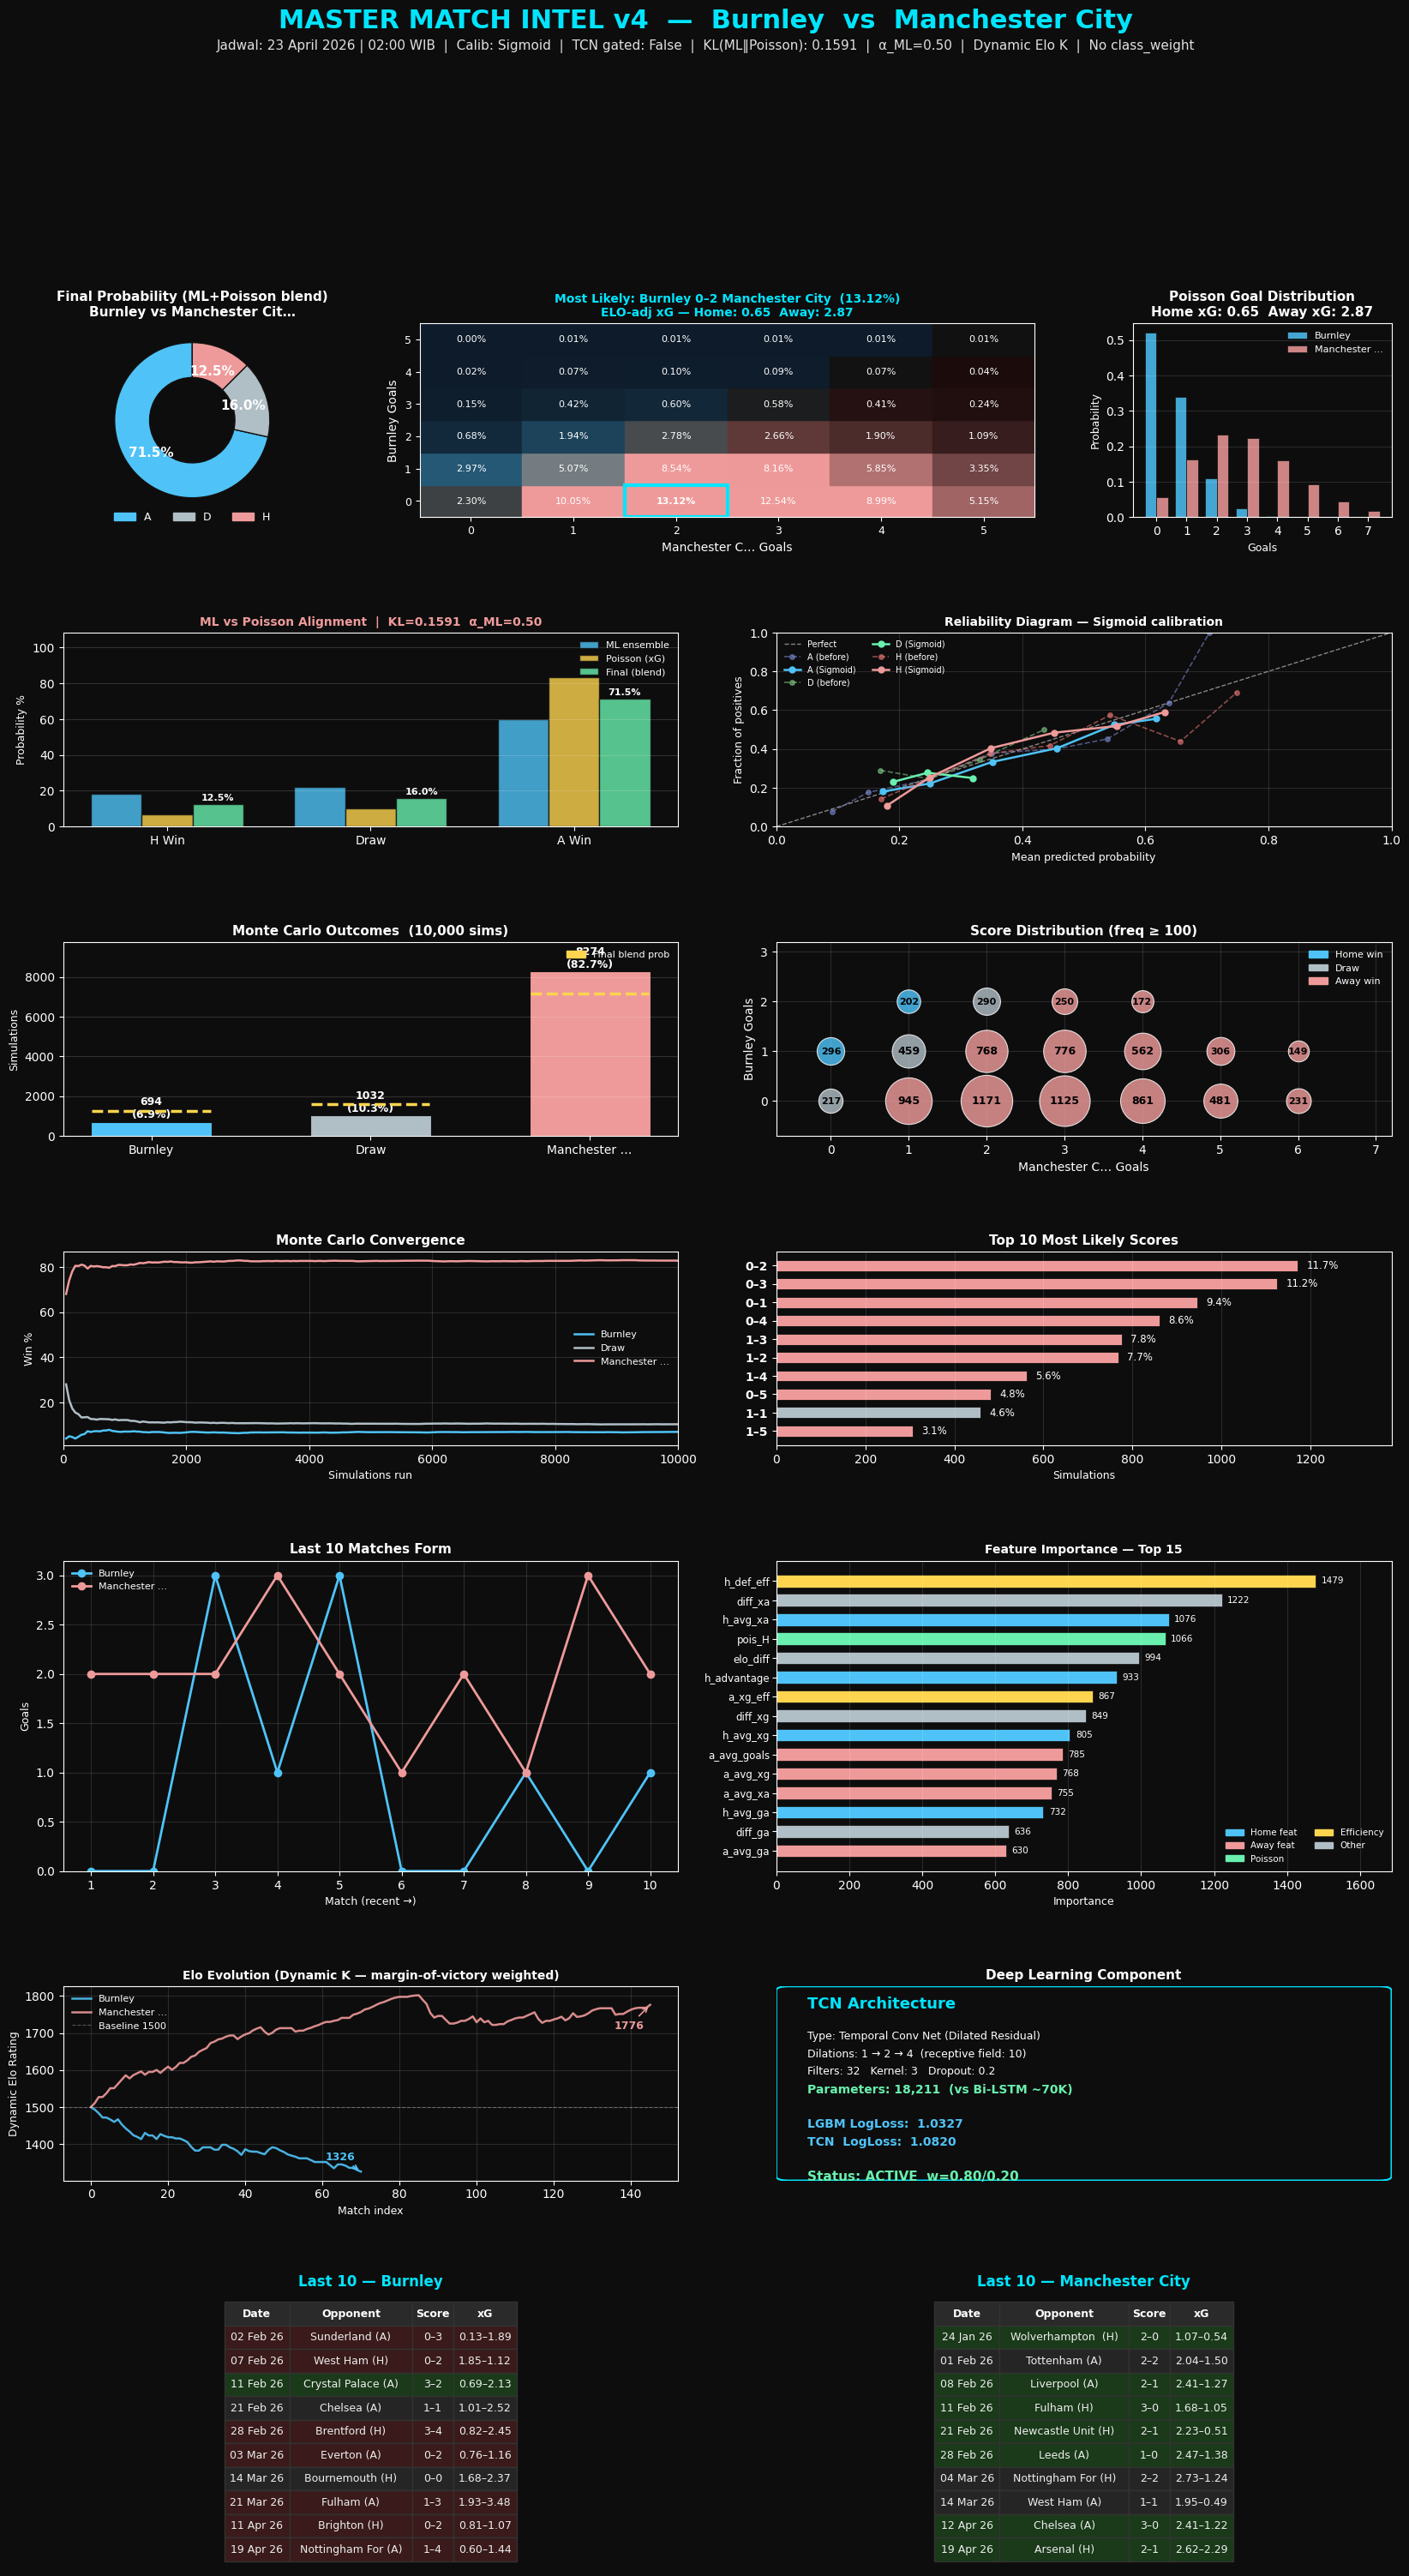

Dashboard v4 berhasil disimpan ke: Match_Intel_v4_Burnley_vs_Manchester_City_2026-04-23_02-00.png


In [16]:
prob, h_xg, a_xg, p_ml_raw, p_pois, kl_div, alpha_ml = predict_match(HOME_TEAM, AWAY_TEAM)
N_SIMS = 10_000
scores, counts, hw, dr, aw, mat = run_monte_carlo(h_xg, a_xg, n_sims=N_SIMS)

print(f"\nFINAL PREDICTION: {HOME_TEAM} vs {AWAY_TEAM}")
for k, v in prob.items():
    print(f"   {k}: {v*100:.1f}%")
print(f"ELO-adj xG → {HOME_TEAM}: {h_xg:.2f}  |  {AWAY_TEAM}: {a_xg:.2f}")
print(f"KL divergence ML vs Poisson: {kl_div:.4f}  (α_ML={alpha_ml:.2f})")
print(f"Monte Carlo: H={hw/N_SIMS*100:.1f}%  D={dr/N_SIMS*100:.1f}%  A={aw/N_SIMS*100:.1f}%")
print(f"TCN gated: {TCN_GATED}  |  Calibration: {best_calib_name}")

understat2 = UnderstatClient()
matches2 = understat2.league("EPL").get_match_data(season=SEASONS[-1])
jadwal_utc = None
for m in matches2:
    if m["h"]["title"] == HOME_TEAM and m["a"]["title"] == AWAY_TEAM and m["goals"]["h"] is None:
        jadwal_utc = pd.to_datetime(m["datetime"]).tz_localize('UTC'); break
if jadwal_utc is None:
    for m in reversed(matches2):
        if m["h"]["title"] == HOME_TEAM and m["a"]["title"] == AWAY_TEAM:
            jadwal_utc = pd.to_datetime(m["datetime"]).tz_localize('UTC'); break
jadwal_wib     = jadwal_utc.tz_convert('Asia/Jakarta')
match_date_str = jadwal_wib.strftime('%d %B %Y | %H:%M WIB')

fig = plt.figure(figsize=(20, 34), facecolor="#0d0d0d")
fig.suptitle(
    f"MASTER MATCH INTEL v4  —  {HOME_TEAM}  vs  {AWAY_TEAM}",
    fontsize=22, fontweight="bold", color=CYAN_HL, y=0.988
)
sub = (f"Jadwal: {match_date_str}  |  Calib: {best_calib_name}  |  "
       f"TCN gated: {TCN_GATED}  |  KL(ML‖Poisson): {kl_div:.4f}  |  α_ML={alpha_ml:.2f}  |  "
       f"Dynamic Elo K  |  No class_weight")
fig.text(0.5, 0.974, sub, ha="center", fontsize=11, color="#e0e0e0")

gs = gridspec.GridSpec(7, 4, figure=fig,
                        hspace=0.52, wspace=0.38,
                        height_ratios=[1, 1, 1, 1, 1.6, 1, 1.4])


ax_donut   = fig.add_subplot(gs[0, 0])
ax_heat    = fig.add_subplot(gs[0, 1:3])
ax_xgdist  = fig.add_subplot(gs[0, 3])
ax_align   = fig.add_subplot(gs[1, 0:2])
ax_relcal  = fig.add_subplot(gs[1, 2:4])
ax_mcbar   = fig.add_subplot(gs[2, 0:2])
ax_bubble  = fig.add_subplot(gs[2, 2:4])
ax_conv    = fig.add_subplot(gs[3, 0:2])
ax_top     = fig.add_subplot(gs[3, 2:4])
ax_form    = fig.add_subplot(gs[4, 0:2])
ax_feat    = fig.add_subplot(gs[4, 2:4])
ax_elo     = fig.add_subplot(gs[5, 0:2])  
ax_tcn     = fig.add_subplot(gs[5, 2:4])  
ax_tbl_h   = fig.add_subplot(gs[6, 0:2])
ax_tbl_a   = fig.add_subplot(gs[6, 2:4])

for ax in fig.get_axes():
    ax.set_facecolor("#0d0d0d")

plot_prob_donut(ax_donut, prob, HOME_TEAM, AWAY_TEAM)
plot_score_heatmap(ax_heat, h_xg, a_xg, HOME_TEAM, AWAY_TEAM)
plot_xg_distribution(ax_xgdist, h_xg, a_xg, HOME_TEAM, AWAY_TEAM)
plot_alignment(ax_align, p_ml_raw, p_pois, prob, kl_div, alpha_ml, HOME_TEAM, AWAY_TEAM)
plot_reliability(ax_relcal, rel_before, rel_after, le)
plot_mc_bar(ax_mcbar, hw, dr, aw, N_SIMS, prob, HOME_TEAM, AWAY_TEAM)
plot_mc_bubble(ax_bubble, counts, N_SIMS, HOME_TEAM, AWAY_TEAM, min_freq=100)
plot_convergence(ax_conv, scores, HOME_TEAM, AWAY_TEAM)
plot_top_scores(ax_top, counts, N_SIMS, HOME_TEAM, AWAY_TEAM)
plot_team_form(ax_form, df, HOME_TEAM, AWAY_TEAM)
plot_feature_importance(ax_feat, lgbm, X)
plot_elo_evolution(ax_elo, df, HOME_TEAM, AWAY_TEAM)
plot_tcn_summary(ax_tcn, tcn_model, ll_lgbm, ll_tcn, TCN_GATED, BEST_WEIGHT)
plot_recent_matches_table(ax_tbl_h, df, HOME_TEAM)
plot_recent_matches_table(ax_tbl_a, df, AWAY_TEAM)

home_safe = HOME_TEAM.replace(" ", "_")
away_safe = AWAY_TEAM.replace(" ", "_")


date_safe = jadwal_wib.strftime("%Y-%m-%d_%H-%M")

filename = f"Match_Intel_v4_{home_safe}_vs_{away_safe}_{date_safe}.png"

plt.savefig(filename, dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

print(f"Dashboard v4 berhasil disimpan ke: {filename}")




<h1>Realtime Dashboard and Predict

In [17]:
import requests
import pandas as pd

API_KEY = "35a4badadd9e7b41101428773faf2bdb"
HEADERS = {"x-apisports-key": API_KEY}

HOME_TEAM = "Banfield"
AWAY_TEAM = "Rivadavia"

def get_fixture_id(home_team, away_team):
    print(f"1. Mencari Fixture ID untuk {home_team} vs {away_team}...")
    
    url_live = "https://v3.football.api-sports.io/fixtures"
    res_live = requests.get(url_live, headers=HEADERS, params={"live": "all"})
    if res_live.status_code == 200:
        for match in res_live.json().get('response', []):
            api_home = match['teams']['home']['name']
            api_away = match['teams']['away']['name']
            if (home_team.lower() in api_home.lower()) and (away_team.lower() in api_away.lower()):
                print(f"Laga LIVE Ditemukan! (ID: {match['fixture']['id']})")
                return match['fixture']['id'], api_home, api_away, "LIVE"

    print("Laga tidak sedang LIVE. Mencari pertandingan terakhir mereka sebagai contoh...")
    url_teams = "https://v3.football.api-sports.io/teams"
    res_team = requests.get(url_teams, headers=HEADERS, params={"search": home_team})
    
    if res_team.status_code == 200 and res_team.json().get('response'):
        team_id = res_team.json()['response'][0]['team']['id']
        res_last = requests.get(url_live, headers=HEADERS, params={"team": team_id, "last": 20})
        if res_last.status_code == 200:
            for match in res_last.json().get('response', []):
                api_home = match['teams']['home']['name']
                api_away = match['teams']['away']['name']
                if away_team.lower() in api_home.lower() or away_team.lower() in api_away.lower():
                    print(f"Laga TERAKHIR Ditemukan! (ID: {match['fixture']['id']})")
                    return match['fixture']['id'], api_home, api_away, "FINISHED"
                    
    print("Gagal menemukan ID pertandingan.")
    return None, None, None, None

def get_full_statistics(fixture_id, home_name, away_name, status):
    print(f"2. Menarik Statistik Full dari API-Football...")
    url_stats = "https://v3.football.api-sports.io/fixtures/statistics"
    
    res = requests.get(url_stats, headers=HEADERS, params={"fixture": fixture_id})
    if res.status_code != 200 or not res.json().get('response'):
        print("Statistik tidak tersedia untuk pertandingan ini.")
        return

    data = res.json()['response']

    stats_home = data[0]['statistics']
    stats_away = data[1]['statistics']

    if data[0]['team']['name'] != home_name:
        stats_home, stats_away = stats_away, stats_home

    stat_types = []
    home_vals = []
    away_vals = []

    for i in range(len(stats_home)):
        stat_name = stats_home[i]['type']
        val_h = stats_home[i]['value']
        val_a = stats_away[i]['value']
        
        val_h = val_h if val_h is not None else 0
        val_a = val_a if val_a is not None else 0

        stat_types.append(stat_name)
        home_vals.append(val_h)
        away_vals.append(val_a)

    df_stats = pd.DataFrame({
        f"{home_name} (HOME)": home_vals,
        "KATEGORI STATISTIK": stat_types,
        f"{away_name} (AWAY)": away_vals
    })

    df_stats = df_stats[[f"{home_name} (HOME)", "KATEGORI STATISTIK", f"{away_name} (AWAY)"]]
    
    print("\n" + "="*60)
    print(f"FULL MATCH STATISTICS ({status})".center(60))
    print("="*60)
    print(df_stats.to_string(index=False, justify='center'))
    print("="*60 + "\n")
fix_id, actual_home, actual_away, match_status = get_fixture_id(HOME_TEAM, AWAY_TEAM)

if fix_id:
    get_full_statistics(fix_id, actual_home, actual_away, match_status)

1. Mencari Fixture ID untuk Banfield vs Rivadavia...
Laga tidak sedang LIVE. Mencari pertandingan terakhir mereka sebagai contoh...
Gagal menemukan ID pertandingan.


In [22]:
HOME_CLR  = "#4fc3f7"   # light blue
AWAY_CLR  = "#ef9a9a"   # light red
DRAW_CLR  = "#b0bec5"   # grey
CYAN_HL   = "#00e5ff"
BG_CLR    = "#0d0d0d"
live_stats = {
    "Shots on Goal": [1, 0],
    "Shots off Goal": [1, 6],
    "Total Shots": [5, 7],
    "Blocked Shots": [3, 1],
    "Shots insidebox": [3, 5],
    "Shots outsidebox": [2, 2],
    "Fouls": [6, 3],
    "Corner Kicks": [2, 2],
    "Offsides": [2, 0],
    "Ball Possession": [44, 56],
    "Yellow Cards": [1, 1],
    "Red Cards": [0, 0],
    "Goalkeeper Saves": [0, 1],
    "Total passes": [116, 149],
    "Passes accurate": [77, 109],
    "Passes %": [66, 73]
}

df_stats = pd.DataFrame(live_stats, index=[HOME_TEAM, AWAY_TEAM]).T

def _truncate(name, n=12):
    return name if len(name) <= n else name[:n] + "…"


<h1>Live Prediction Engine 

In [23]:
def calculate_live_xg(stats_dict):
    WEIGHT_SOT, WEIGHT_SOFF, WEIGHT_BOX = 0.25, 0.05, 0.10
    
    h_xg = (stats_dict["Shots on Goal"][0] * WEIGHT_SOT) + (stats_dict["Shots off Goal"][0] * WEIGHT_SOFF) + (stats_dict["Shots insidebox"][0] * WEIGHT_BOX)
    a_xg = (stats_dict["Shots on Goal"][1] * WEIGHT_SOT) + (stats_dict["Shots off Goal"][1] * WEIGHT_SOFF) + (stats_dict["Shots insidebox"][1] * WEIGHT_BOX)
    
    h_xg *= (1 + ((stats_dict["Ball Possession"][0] / 100) - 0.5))
    a_xg *= (1 + ((stats_dict["Ball Possession"][1] / 100) - 0.5))
    
    return max(h_xg, 0.15), max(a_xg, 0.15)

def dixon_coles_adj(i, j, hx, ax, rho=0.15):
    if i == 0 and j == 0: return 1 - hx * ax * rho
    if i == 1 and j == 0: return 1 + ax * rho
    if i == 0 and j == 1: return 1 + hx * rho
    if i == 1 and j == 1: return 1 - rho
    return 1.0

def run_live_monte_carlo(hx, ax, n_sims=10000, max_goals=6):
    N = max_goals + 1
    mat = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            mat[i, j] = (poisson.pmf(i, hx) * poisson.pmf(j, ax) * dixon_coles_adj(i, j, hx, ax))
    mat /= mat.sum()
    
    flat = mat.flatten()
    idx = np.random.choice(len(flat), size=n_sims, p=flat)
    h_sc, a_sc = idx // N, idx % N
    
    prob = {
        HOME_TEAM: int((h_sc > a_sc).sum()) / n_sims,
        "Draw": int((h_sc == a_sc).sum()) / n_sims,
        AWAY_TEAM: int((h_sc < a_sc).sum()) / n_sims
    }
    return prob, mat
live_h_xg, live_a_xg = calculate_live_xg(live_stats)
N_SIMS = 10000
live_probs, score_mat = run_live_monte_carlo(live_h_xg, live_a_xg, n_sims=N_SIMS)


<h1>Visualization

In [25]:
def plot_possession_donut(ax, home_val, away_val):
    wedges, _ = ax.pie([home_val, away_val], colors=[HOME_CLR, AWAY_CLR], startangle=90, wedgeprops=dict(width=0.35, edgecolor="#111"))
    ax.text(0, 0.15, "POSSESSION", ha="center", va="center", fontsize=10, color="#b0bec5", fontweight="bold")
    ax.text(-0.5, -0.15, f"{home_val}%", ha="center", va="center", fontsize=16, fontweight="bold", color=HOME_CLR)
    ax.text(0.5, -0.15, f"{away_val}%", ha="center", va="center", fontsize=16, fontweight="bold", color=AWAY_CLR)
    ax.set_title("Penguasaan Bola", fontsize=12, fontweight="bold", pad=15)

def plot_comparison_bar(ax, df, metrics, title):
    y_pos = np.arange(len(metrics))
    home_vals = [df.loc[m, HOME_TEAM] for m in metrics]
    away_vals = [df.loc[m, AWAY_TEAM] for m in metrics]

    max_val = max(max(home_vals), max(away_vals))
    ax.set_xlim(-max_val * 1.35, max_val * 1.35) 

    ax.barh(y_pos, [-v for v in home_vals], color=HOME_CLR, edgecolor=BG_CLR, height=0.5, zorder=1)
    ax.barh(y_pos, away_vals, color=AWAY_CLR, edgecolor=BG_CLR, height=0.5, zorder=1)
    ax.axvline(0, color='white', linewidth=1.5, alpha=0.2, zorder=0)

    for i, (hv, av, m) in enumerate(zip(home_vals, away_vals, metrics)):
        ax.text(-hv - (max_val*0.04), i, str(hv), va='center', ha='right', color='white', fontweight='bold', fontsize=10, zorder=3)
        ax.text(av + (max_val*0.04), i, str(av), va='center', ha='left', color='white', fontweight='bold', fontsize=10, zorder=3)
        ax.text(0, i, m, ha='center', va='center', color='white', fontweight='bold', fontsize=10, 
                bbox=dict(facecolor=BG_CLR, edgecolor='none', pad=4), zorder=4)

    ax.set_yticks([])
    for spine in ['top', 'right', 'bottom', 'left']: ax.spines[spine].set_visible(False)
    ax.get_xaxis().set_ticks([])
    ax.set_title(title, fontsize=12, fontweight="bold", pad=20)

def plot_passing_accuracy(ax, home_acc, away_acc):
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.9, "Akurasi Umpan", ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax.text(0.25, 0.6, _truncate(HOME_TEAM, 12), ha='right', va='center', fontsize=11, color=HOME_CLR, fontweight='bold')
    ax.add_patch(mpatches.Rectangle((0.28, 0.55), 0.55, 0.1, color="#333"))
    ax.add_patch(mpatches.Rectangle((0.28, 0.55), 0.55 * (home_acc/100), 0.1, color=HOME_CLR))
    ax.text(0.85, 0.6, f"{home_acc}%", ha='left', va='center', fontsize=11, color='white', fontweight='bold')

    ax.text(0.25, 0.3, _truncate(AWAY_TEAM, 12), ha='right', va='center', fontsize=11, color=AWAY_CLR, fontweight='bold')
    ax.add_patch(mpatches.Rectangle((0.28, 0.25), 0.55, 0.1, color="#333"))
    ax.add_patch(mpatches.Rectangle((0.28, 0.25), 0.55 * (away_acc/100), 0.1, color=AWAY_CLR))
    ax.text(0.85, 0.3, f"{away_acc}%", ha='left', va='center', fontsize=11, color='white', fontweight='bold')

def plot_prediction_donut(ax, probs):
    colors = [HOME_CLR, DRAW_CLR, AWAY_CLR]
    wedges, _ = ax.pie(list(probs.values()), colors=colors, startangle=90, wedgeprops=dict(width=0.45, edgecolor="#111"))
    
    for w, v in zip(wedges, list(probs.values())):
        ang = (w.theta1 + w.theta2) / 2
        ax.text(0.7 * np.cos(np.radians(ang)), 0.7 * np.sin(np.radians(ang)), f"{v*100:.1f}%", ha="center", va="center", fontsize=12, fontweight="bold", color="white")

    ax.text(0, 0, "MATCH\nPROBABILITY", ha="center", va="center", fontsize=11, fontweight="bold", color="white")
    legend_items = [mpatches.Patch(color=c, label=k) for k, c in zip(probs.keys(), colors)]
    ax.legend(handles=legend_items, loc="lower center", ncol=3, fontsize=10, framealpha=0, bbox_to_anchor=(0.5, -0.15))
    ax.set_title("Simulasi W/D/L", fontsize=12, fontweight="bold", pad=15)

def plot_score_heatmap(ax, mat, max_g=4):
    disp = mat[:max_g+1, :max_g+1]
    best_score = np.unravel_index(np.argmax(disp), disp.shape)

    cmap_hw = LinearSegmentedColormap.from_list("hw", ["#0d1b2a", HOME_CLR])
    cmap_aw = LinearSegmentedColormap.from_list("aw", ["#1b0a0a", AWAY_CLR])
    cmap_dr = LinearSegmentedColormap.from_list("dr", ["#111", DRAW_CLR])

    for i in range(max_g+1):
        for j in range(max_g+1):
            v = disp[i, j]
            c = cmap_hw(v / disp.max() * 1.5) if i > j else (cmap_aw(v / disp.max() * 1.5) if i < j else cmap_dr(v / disp.max() * 1.5))
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=c))
            fw, fs = ("bold", 12) if (i, j) == best_score else ("normal", 9)
            ax.text(j + 0.5, i + 0.5, f"{v*100:.1f}%", ha="center", va="center", fontsize=fs, color="white", fontweight=fw)

    ax.add_patch(plt.Rectangle((best_score[1], best_score[0]), 1, 1, fill=False, edgecolor=CYAN_HL, lw=3, zorder=5))
    ax.set_xlim(0, max_g+1); ax.set_ylim(0, max_g+1)
    ax.set_xticks(np.arange(max_g+1) + 0.5); ax.set_xticklabels(range(max_g+1), fontsize=10)
    ax.set_yticks(np.arange(max_g+1) + 0.5); ax.set_yticklabels(range(max_g+1), fontsize=10)
    ax.set_xlabel(f"Gol {_truncate(AWAY_TEAM)}", fontsize=11, fontweight="bold")
    ax.set_ylabel(f"Gol {_truncate(HOME_TEAM)}", fontsize=11, fontweight="bold")
    ax.set_title(f"Prediksi Skor Terkuat: {HOME_TEAM} {best_score[0]} - {best_score[1]} {AWAY_TEAM} ({disp[best_score]*100:.1f}%)", fontsize=12, fontweight="bold", color=CYAN_HL, pad=15)

<h1>Render and Save Results

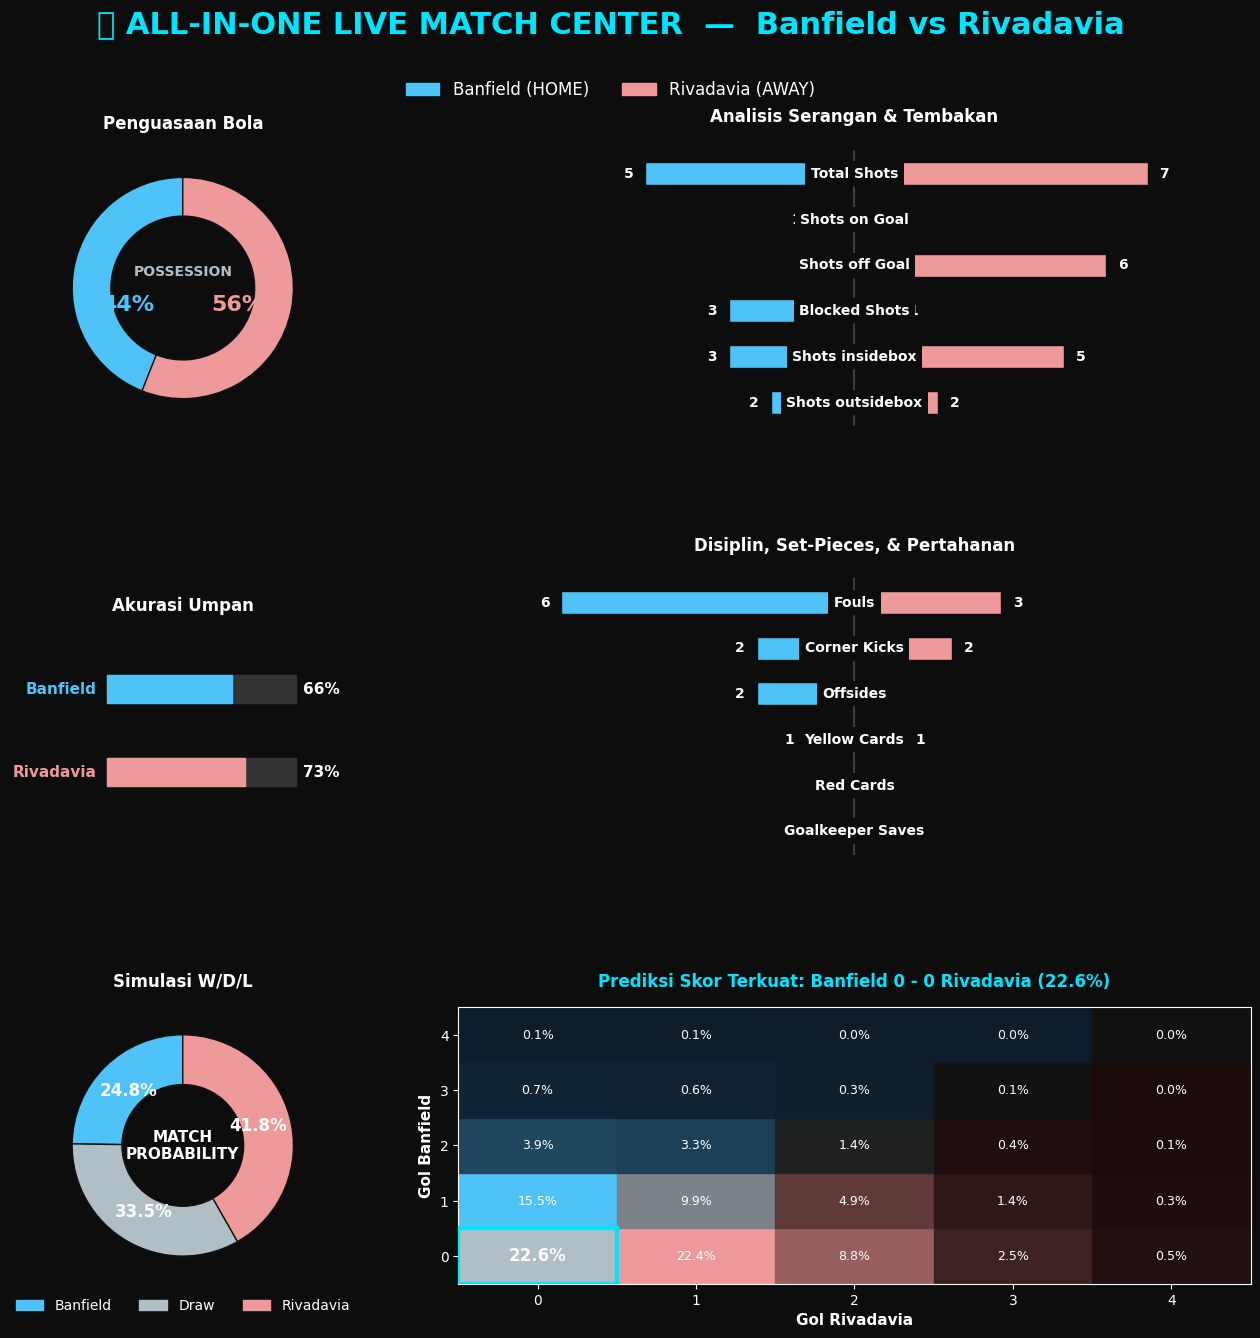

Dashboard lengkap berhasil disimpan dengan nama: Banfield_vs_Rivadavia_2026-04-21_0200.png


In [27]:
fig = plt.figure(figsize=(16, 14), facecolor=BG_CLR)
fig.suptitle(f"📡 ALL-IN-ONE LIVE MATCH CENTER  —  {HOME_TEAM} vs {AWAY_TEAM}", fontsize=22, fontweight="bold", color=CYAN_HL, y=0.96)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.3)

ax_poss       = fig.add_subplot(gs[0, 0])
ax_shots      = fig.add_subplot(gs[0, 1:3])
ax_pass       = fig.add_subplot(gs[1, 0])
ax_disc       = fig.add_subplot(gs[1, 1:3])
ax_pred_donut = fig.add_subplot(gs[2, 0])
ax_pred_heat  = fig.add_subplot(gs[2, 1:3])

for ax in fig.get_axes(): ax.set_facecolor(BG_CLR)

plot_possession_donut(ax_poss, df_stats.loc["Ball Possession", HOME_TEAM], df_stats.loc["Ball Possession", AWAY_TEAM])
plot_comparison_bar(ax_shots, df_stats, ["Total Shots", "Shots on Goal", "Shots off Goal", "Blocked Shots", "Shots insidebox", "Shots outsidebox"][::-1], "Analisis Serangan & Tembakan")
plot_passing_accuracy(ax_pass, df_stats.loc["Passes %", HOME_TEAM], df_stats.loc["Passes %", AWAY_TEAM])
plot_comparison_bar(ax_disc, df_stats, ["Fouls", "Corner Kicks", "Offsides", "Yellow Cards", "Red Cards", "Goalkeeper Saves"][::-1], "Disiplin, Set-Pieces, & Pertahanan")

plot_prediction_donut(ax_pred_donut, live_probs)
plot_score_heatmap(ax_pred_heat, score_mat)
legend_elements = [mpatches.Patch(color=HOME_CLR, label=f'{HOME_TEAM} (HOME)'), mpatches.Patch(color=AWAY_CLR, label=f'{AWAY_TEAM} (AWAY)')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=2, frameon=False, fontsize=12)
fig.subplots_adjust(top=0.86, bottom=0.05)

file_time_str = jadwal_wib.strftime('%Y-%m-%d_%H%M')
filename = f"{HOME_TEAM.replace(' ', '_')}_vs_{AWAY_TEAM.replace(' ', '_')}_{file_time_str}.png"

plt.savefig(filename, dpi=150, bbox_inches="tight", facecolor=BG_CLR)
plt.show()

print(f"Dashboard lengkap berhasil disimpan dengan nama: {filename}")